# 04 — Product Recommendation ML (Pipeline v2)
**Merchant Network Analytics — Capstone Project BNI ODP**

---

## Tujuan

Memprediksi layanan pembayaran yang sesuai untuk merchant:

- **Kelas 0 — QRIS:** kebutuhan pembayaran dasar.
- **Kelas 1 — QRIS + EDC:** membutuhkan kanal pembayaran fisik tambahan.

Model dilatih menggunakan merchant BNI existing yang produknya sudah diketahui, lalu digunakan untuk memberi rekomendasi kepada merchant non-BNI.

## Perbaikan metodologi pada versi ini

1. Split train-test dilakukan **sebelum** preprocessing.
2. Imputasi, scaling, one-hot encoding, dan resampling berada di dalam `Pipeline`.
3. Resampling hanya terjadi pada data train di setiap fold cross-validation, sehingga tidak bocor ke validation/test.
4. Pemilihan model memakai cross-validation pada train set; test set hanya dipakai sekali untuk evaluasi final.
5. Pipeline produksi di-refit pada seluruh data berlabel dan dapat menerima data mentah tanpa encoding manual.

> Catatan: notebook membandingkan distribusi asli, `SMOTE`, dan `SMOTENC`. SMOTE biasa menjadi baseline sintetis setelah one-hot encoding, sedangkan SMOTENC adalah opsi yang lebih tepat untuk campuran fitur numerik-kategorikal.

**Input utama:** `data/processed/feature_table.csv`  
**Output utama:** `models/product_rec_pipeline.pkl`, `models/product_rec_model.pkl`, dan `data/processed/merchants_with_product_rec.csv`


In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from IPython.display import display
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
SAVE_OUTPUTS = True  # Ubah ke False jika hanya ingin mencoba notebook tanpa menulis artefak.

PROJECT_ROOT = "." if os.path.isdir("./data") else ".."
DATA_DIR = f"{PROJECT_ROOT}/data/processed"
MODEL_DIR = f"{PROJECT_ROOT}/models"
PLOT_DIR = f"{PROJECT_ROOT}/notebooks/plots"

feature_table = pd.read_csv(f"{DATA_DIR}/feature_table.csv")
print(f"Feature table: {feature_table.shape[0]:,} baris x {feature_table.shape[1]} kolom")

Feature table: 708 baris x 35 kolom


## 1. Menyiapkan target

Label hanya dibuat dari merchant BNI existing:

- produk mengandung `EDC` → kelas 1;
- produk hanya mengandung `QRIS` → kelas 0;
- produk lain/tidak dikenal tidak digunakan untuk training.

Kolom produk dan status nasabah hanya dipakai untuk membentuk sampel/target, **bukan sebagai fitur model**.


Total data berlabel : 462 merchant
Imbalance ratio     : 1.17:1
Minority proportion : 46.1%
Diagnosis awal       : relatif seimbang
Keputusan resampling tidak hanya berdasarkan proporsi; None, SMOTE, dan SMOTENC akan dibandingkan lewat CV.


,jumlah,persentase
product_label,,
QRIS,213,46.1
QRIS + EDC,249,53.9


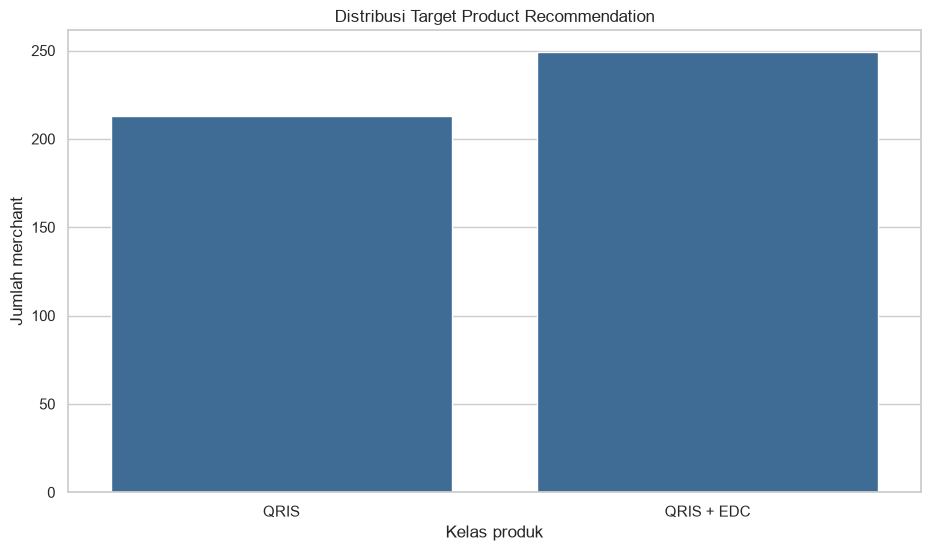

In [2]:
REQUIRED_SOURCE_COLS = {"merchant_id", "is_bni_acquiring", "produk_bni"}
missing_source_cols = REQUIRED_SOURCE_COLS.difference(feature_table.columns)
if missing_source_cols:
    raise ValueError(f"Kolom input wajib tidak ditemukan: {sorted(missing_source_cols)}")


def assign_product_label(product):
    # Map produk existing menjadi target biner; produk lain dikembalikan sebagai NaN.
    if pd.isna(product):
        return np.nan

    product_upper = str(product).upper()
    if "EDC" in product_upper:
        return 1
    if "QRIS" in product_upper:
        return 0
    return np.nan


labeled_merchants = feature_table.loc[
    feature_table["is_bni_acquiring"].eq("Ya")
].copy()
labeled_merchants["product_label"] = labeled_merchants["produk_bni"].apply(
    assign_product_label
)
labeled_merchants = labeled_merchants.dropna(subset=["product_label"]).copy()
labeled_merchants["product_label"] = labeled_merchants["product_label"].astype(int)

label_summary = (
    labeled_merchants["product_label"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .rename(index={0: "QRIS", 1: "QRIS + EDC"})
    .to_frame("jumlah")
)
label_summary["persentase"] = 100 * label_summary["jumlah"] / label_summary["jumlah"].sum()

class_counts = labeled_merchants["product_label"].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
minority_percentage = 100 * class_counts.min() / class_counts.sum()

if imbalance_ratio < 1.5:
    imbalance_level = "relatif seimbang"
elif imbalance_ratio < 3.0:
    imbalance_level = "imbalance ringan–moderat"
else:
    imbalance_level = "imbalance berat"

print(f"Total data berlabel : {len(labeled_merchants):,} merchant")
print(f"Imbalance ratio     : {imbalance_ratio:.2f}:1")
print(f"Minority proportion : {minority_percentage:.1f}%")
print(f"Diagnosis awal       : {imbalance_level}")
print(
    "Keputusan resampling tidak hanya berdasarkan proporsi; "
    "None, SMOTE, dan SMOTENC akan dibandingkan lewat CV."
)
display(label_summary.round({"persentase": 1}))

ax = sns.countplot(
    data=labeled_merchants,
    x="product_label",
    order=[0, 1],
    color="#2f6da4",
)
ax.set(
    title="Distribusi Target Product Recommendation",
    xlabel="Kelas produk",
    ylabel="Jumlah merchant",
    xticklabels=["QRIS", "QRIS + EDC"],
)
plt.show()

## 2. Fitur dan holdout split

Fitur dipilih secara ringkas agar mudah dijelaskan. Versi log digunakan untuk variabel yang sangat skewed; versi mentahnya tidak dimasukkan bersamaan agar tidak redundan. `community_id` juga tidak dipakai karena angka ID komunitas bukan besaran numerik yang memiliki urutan.

Pipeline tetap memiliki imputasi meskipun data saat ini lengkap, sehingga inferensi lebih aman bila data baru mengandung nilai kosong.


In [3]:
NUMERIC_FEATURES = [
    "log_omzet",
    "degree",
    "log_weighted_degree",
    "log_pagerank",
    "betweenness",
    "community_size",
    "connected_bni_ratio",
    "avg_neighbor_jaccard",
    "log_n_customers",
    "lama_beroperasi_tahun",
    "jumlah_karyawan",
    "rating_google",
    "jumlah_outlet",
    "has_rating",
    "has_website",
    "has_social_media",
    "is_hub",
    "customer_density",
]

CATEGORICAL_FEATURES = ["kategori", "kota"]
PRODUCT_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

missing_features = sorted(set(PRODUCT_FEATURES).difference(feature_table.columns))
if missing_features:
    raise ValueError(f"Fitur berikut tidak ditemukan di feature_table: {missing_features}")

X_product = labeled_merchants[PRODUCT_FEATURES].copy()
y_product = labeled_merchants["product_label"].copy()

# Holdout dibuat sebelum transformer apa pun di-fit.
X_train, X_test, y_train, y_test = train_test_split(
    X_product,
    y_product,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_product,
)

print(f"Jumlah fitur : {len(PRODUCT_FEATURES)}")
print(f"Train        : {X_train.shape} | distribusi {y_train.value_counts().to_dict()}")
print(f"Test         : {X_test.shape} | distribusi {y_test.value_counts().to_dict()}")


Jumlah fitur : 20
Train        : (369, 20) | distribusi {1: 199, 0: 170}
Test         : (93, 20) | distribusi {1: 50, 0: 43}


## 3. Pipeline preprocessing, balancing, dan model

Tiga strategi dibandingkan secara adil di dalam fold cross-validation:

1. **None** — model belajar dari distribusi asli tanpa oversampling.
2. **SMOTE** — kategori di-one-hot terlebih dahulu, lalu sampel sintetis dibuat pada ruang fitur hasil encoding.
3. **SMOTENC** — kategori di-ordinal encode sementara, SMOTE dijalankan dengan penanda fitur kategorikal, lalu kategori di-one-hot setelah resampling.

SMOTE biasa tetap disertakan sebagai pembanding, tetapi memiliki keterbatasan: interpolasi setelah one-hot encoding dapat menghasilkan nilai dummy pecahan. Karena itu, untuk data campuran seperti ini, SMOTENC secara metodologis lebih sesuai. Scaling numerik dilakukan sebelum kedua sampler agar perhitungan jarak tidak didominasi fitur berskala besar.

Semua preprocessing dan oversampling berada di dalam pipeline. Dengan demikian, sampler hanya menerima bagian training pada setiap fold dan tidak menyebabkan leakage ke validation/test.

In [4]:
NUMERIC_INDICES = list(range(len(NUMERIC_FEATURES)))
CATEGORICAL_INDICES = list(
    range(len(NUMERIC_FEATURES), len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES))
)
SAMPLER_NAMES = ["None", "SMOTE", "SMOTENC"]


def make_onehot_preprocessor():
    # Dipakai oleh None dan SMOTE.
    numeric_transformer = SklearnPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_transformer = SklearnPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, NUMERIC_FEATURES),
            ("categorical", categorical_transformer, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        sparse_threshold=0,
        verbose_feature_names_out=False,
    )


def make_smotenc_preprocessor():
    # SMOTENC membutuhkan posisi kategorikal yang eksplisit sebelum one-hot encoding.
    numeric_transformer = SklearnPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_transformer = SklearnPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "ordinal",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, NUMERIC_FEATURES),
            ("categorical", categorical_transformer, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        sparse_threshold=0,
        verbose_feature_names_out=False,
    )


def make_smotenc_postprocessor():
    return ColumnTransformer(
        transformers=[
            ("numeric", "passthrough", NUMERIC_INDICES),
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                CATEGORICAL_INDICES,
            ),
        ],
        remainder="drop",
        sparse_threshold=0,
        verbose_feature_names_out=False,
    )


def make_pipeline(model, sampler_name="None"):
    if sampler_name not in SAMPLER_NAMES:
        raise ValueError(f"Sampler tidak dikenal: {sampler_name}")

    if sampler_name == "SMOTENC":
        return Pipeline(
            steps=[
                ("preprocess", make_smotenc_preprocessor()),
                (
                    "balance",
                    SMOTENC(
                        categorical_features=CATEGORICAL_INDICES,
                        random_state=RANDOM_STATE,
                        k_neighbors=5,
                    ),
                ),
                ("postprocess", make_smotenc_postprocessor()),
                ("model", model),
            ]
        )

    sampler = (
        SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
        if sampler_name == "SMOTE"
        else "passthrough"
    )
    return Pipeline(
        steps=[
            ("preprocess", make_onehot_preprocessor()),
            ("balance", sampler),
            ("model", model),
        ]
    )


model_specs = {
    "Logistic Regression": LogisticRegression(
        max_iter=3_000,
        solver="liblinear",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

dummy_pipeline = make_pipeline(
    DummyClassifier(strategy="prior", random_state=RANDOM_STATE),
    sampler_name="None",
)

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

SCORING = {
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
}

## 4. Perbandingan model dan strategi imbalance dengan cross-validation

Macro-F1 menjadi metrik seleksi karena memberi bobot yang sama kepada QRIS dan QRIS + EDC. Ini lebih informatif daripada F1 kelas 1 saja ketika distribusi kelas tidak seimbang.

Setiap model diuji dengan tiga strategi: distribusi asli (`None`), `SMOTE`, dan `SMOTENC`. Seluruh perbandingan hanya menggunakan `X_train`; `X_test` belum disentuh pada tahap ini.

In [5]:
cv_rows = []

# Dummy baseline: batas minimum yang perlu dilampaui model.
dummy_scores = cross_validate(
    dummy_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=SCORING,
    n_jobs=1,
    error_score="raise",
)
cv_rows.append(
    {
        "Model": "Dummy Majority",
        "Sampler": "None",
        "CV Macro-F1 Mean": dummy_scores["test_macro_f1"].mean(),
        "CV Macro-F1 Std": dummy_scores["test_macro_f1"].std(),
        "CV Balanced Accuracy": dummy_scores["test_balanced_accuracy"].mean(),
        "CV ROC-AUC": dummy_scores["test_roc_auc"].mean(),
    }
)

for model_name, model in model_specs.items():
    for sampler_name in SAMPLER_NAMES:
        candidate_pipeline = make_pipeline(
            clone(model),
            sampler_name=sampler_name,
        )
        scores = cross_validate(
            candidate_pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=SCORING,
            n_jobs=1,
            error_score="raise",
        )

        cv_rows.append(
            {
                "Model": model_name,
                "Sampler": sampler_name,
                "CV Macro-F1 Mean": scores["test_macro_f1"].mean(),
                "CV Macro-F1 Std": scores["test_macro_f1"].std(),
                "CV Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
                "CV ROC-AUC": scores["test_roc_auc"].mean(),
            }
        )

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values("CV Macro-F1 Mean", ascending=False)
    .reset_index(drop=True)
)
display(cv_results.round(4))

eligible_results = cv_results.loc[cv_results["Model"] != "Dummy Majority"]
selected_model_name = eligible_results.iloc[0]["Model"]
selected_sampler_name = eligible_results.iloc[0]["Sampler"]
dummy_macro_f1 = cv_results.loc[
    cv_results["Model"].eq("Dummy Majority"), "CV Macro-F1 Mean"
].iloc[0]
selected_macro_f1 = eligible_results.iloc[0]["CV Macro-F1 Mean"]

sampler_comparison = (
    eligible_results.groupby("Sampler", as_index=False)["CV Macro-F1 Mean"]
    .max()
    .sort_values("CV Macro-F1 Mean", ascending=False)
)
print("Macro-F1 terbaik untuk setiap strategi:")
display(sampler_comparison.round(4))
print(f"Kandidat awal terbaik: {selected_model_name} + {selected_sampler_name}")

if selected_macro_f1 <= dummy_macro_f1:
    print(
        "PERINGATAN: model belum mengungguli dummy baseline secara konsisten. "
        "Hasil tetap dapat dipakai sebagai eksperimen capstone, tetapi jangan "
        "mengklaim kemampuan prediksi yang kuat."
    )

,Model,Sampler,CV Macro-F1 Mean,CV Macro-F1 Std,CV Balanced Accuracy,CV ROC-AUC
0,Logistic Regression,SMOTENC,0.7544,0.0340,0.7554,0.8109
1,Logistic Regression,None,0.7373,0.0386,0.7382,0.8092
2,XGBoost,SMOTENC,0.7313,0.0237,0.7340,0.7799
3,Random Forest,SMOTENC,0.7308,0.0502,0.7346,0.7847
4,Logistic Regression,SMOTE,0.7300,0.0318,0.7311,0.8108
5,XGBoost,SMOTE,0.7287,0.0355,0.7319,0.7798
6,Random Forest,SMOTE,0.7286,0.0373,0.7317,0.7770
7,Random Forest,None,0.7256,0.0271,0.7282,0.7791
8,XGBoost,None,0.7231,0.0433,0.7264,0.7843
9,Dummy Majority,None,0.3503,0.0011,0.5000,0.5000


Macro-F1 terbaik untuk setiap strategi:


,Sampler,CV Macro-F1 Mean
2,SMOTENC,0.7544
0,None,0.7373
1,SMOTE,0.7300


Kandidat awal terbaik: Logistic Regression + SMOTENC


## 5. Hyperparameter tuning terkontrol

Grid memberi variasi regularisasi dan kompleksitas model tanpa membuat eksperimen berlebihan. Setelah keluarga model terbaik ditentukan, **model tersebut dituning tiga kali secara terpisah** dengan `None`, `SMOTE`, dan `SMOTENC`. Strategi dengan CV Macro-F1 terbaik menjadi pipeline final.

Dengan cara ini, perbandingan strategi tetap adil meskipun SMOTE dan SMOTENC membutuhkan susunan preprocessing yang berbeda.

In [6]:
selected_model = clone(model_specs[selected_model_name])

param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        "model__penalty": ["l1", "l2"],
    },
    "Random Forest": {
        "model__n_estimators": [100, 250, 400, 600],
        "model__max_depth": [None, 6, 12],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
    },
    "XGBoost": {
        "model__n_estimators": [100, 250, 400, 600],
        "model__max_depth": [2, 4],
        "model__learning_rate": [0.03, 0.10],
        "model__min_child_weight": [1, 3],
        "model__subsample": [0.8, 1.0],
    },
}

grid_searches = {}
tuning_rows = []

for sampler_name in SAMPLER_NAMES:
    tuning_pipeline = make_pipeline(
        clone(selected_model),
        sampler_name=sampler_name,
    )
    search = GridSearchCV(
        estimator=tuning_pipeline,
        param_grid=param_grids[selected_model_name],
        scoring="f1_macro",
        cv=cv,
        refit=True,
        n_jobs=1,
        verbose=0,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    grid_searches[sampler_name] = search
    tuning_rows.append(
        {
            "Sampler": sampler_name,
            "Jumlah Kombinasi": len(search.cv_results_["params"]),
            "Best CV Macro-F1": search.best_score_,
            "Best Params": search.best_params_,
        }
    )

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values("Best CV Macro-F1", ascending=False)
    .reset_index(drop=True)
)
display(tuning_results.round({"Best CV Macro-F1": 4}))

selected_sampler_name = tuning_results.iloc[0]["Sampler"]
grid_search = grid_searches[selected_sampler_name]
best_params_display = grid_search.best_params_.copy()

print(f"Model final       : {selected_model_name}")
print(f"Strategi final    : {selected_sampler_name}")
print(f"Best CV Macro-F1 : {grid_search.best_score_:.4f}")
print(f"Best params      : {best_params_display}")

,Sampler,Jumlah Kombinasi,Best CV Macro-F1,Best Params
0,SMOTENC,10,0.7544,"{'model__C': 1.0, 'model__penalty': 'l2'}"
1,SMOTE,10,0.7512,"{'model__C': 0.1, 'model__penalty': 'l1'}"
2,None,10,0.7486,"{'model__C': 1.0, 'model__penalty': 'l1'}"


Model final       : Logistic Regression
Strategi final    : SMOTENC
Best CV Macro-F1 : 0.7544
Best params      : {'model__C': 1.0, 'model__penalty': 'l2'}


## 6. Evaluasi final pada holdout

Test set digunakan di bagian ini untuk pertama kalinya. Nilai ini adalah estimasi performa generalisasi yang dilaporkan. Model tidak dipilih ulang berdasarkan hasil test.


,Holdout score
accuracy,0.7742
balanced_accuracy,0.7786
precision_edc,0.8372
recall_edc,0.7200
f1_edc,0.7742
macro_f1,0.7742
roc_auc,0.8274


              precision    recall  f1-score   support

        QRIS       0.72      0.84      0.77        43
  QRIS + EDC       0.84      0.72      0.77        50

    accuracy                           0.77        93
   macro avg       0.78      0.78      0.77        93
weighted avg       0.78      0.77      0.77        93



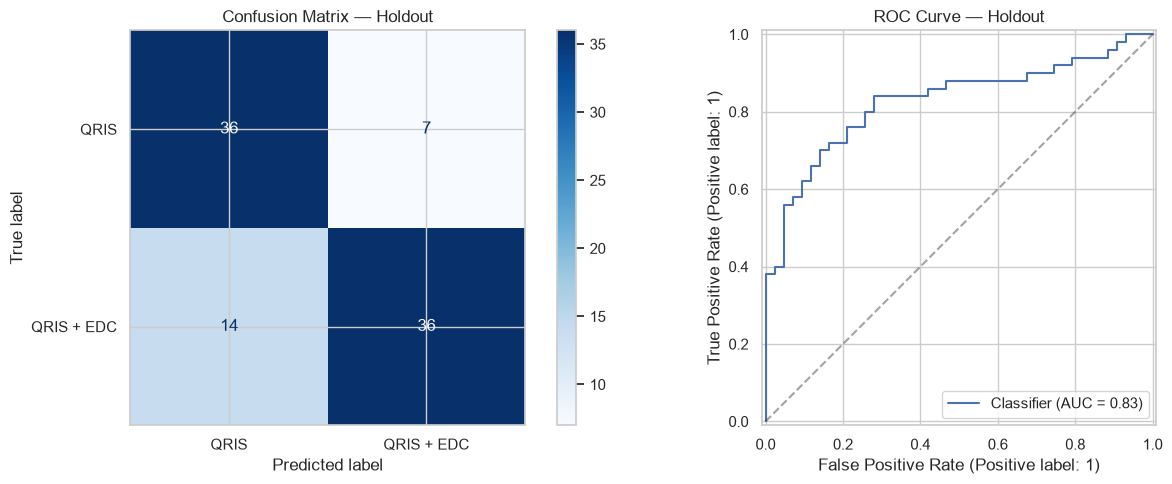

In [7]:
evaluation_pipeline = grid_search.best_estimator_
y_test_pred = evaluation_pipeline.predict(X_test)
y_test_proba = evaluation_pipeline.predict_proba(X_test)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
    "precision_edc": precision_score(y_test, y_test_pred, zero_division=0),
    "recall_edc": recall_score(y_test, y_test_pred, zero_division=0),
    "f1_edc": f1_score(y_test, y_test_pred, zero_division=0),
    "macro_f1": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_test_proba),
}

display(pd.Series(test_metrics, name="Holdout score").to_frame().round(4))
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=[0, 1],
        target_names=["QRIS", "QRIS + EDC"],
        zero_division=0,
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["QRIS", "QRIS + EDC"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix — Holdout")

RocCurveDisplay.from_predictions(y_test, y_test_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("ROC Curve — Holdout")

plt.tight_layout()
if SAVE_OUTPUTS:
    os.makedirs(PLOT_DIR, exist_ok=True)
    plt.savefig(f"{PLOT_DIR}/19_product_rec_evaluation_v2.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Model feature importance

Interpretasi pertama menggunakan ukuran bawaan model final:

- **Logistic Regression:** nilai absolut koefisien; tanda positif mengarah ke QRIS + EDC dan tanda negatif mengarah ke QRIS.
- **Random Forest/XGBoost:** impurity/gain-based feature importance.

Nilai dihitung setelah preprocessing. Karena kategori sudah di-one-hot, kategori tertentu dapat muncul sebagai fitur tersendiri.

,feature,importance,signed_effect,direction
0,log_omzet,1.6876,1.6876,Mendorong QRIS + EDC
1,log_n_customers,0.8102,-0.8102,Mendorong QRIS
2,kota_2.0,0.7697,0.7697,Mendorong QRIS + EDC
3,kategori_2.0,0.6872,-0.6872,Mendorong QRIS
4,kategori_0.0,0.4957,0.4957,Mendorong QRIS + EDC
5,kategori_1.0,0.4947,0.4947,Mendorong QRIS + EDC
6,kota_5.0,0.4080,-0.4080,Mendorong QRIS
7,is_hub,0.3579,-0.3579,Mendorong QRIS
8,connected_bni_ratio,0.3561,-0.3561,Mendorong QRIS
9,kategori_4.0,0.3477,-0.3477,Mendorong QRIS


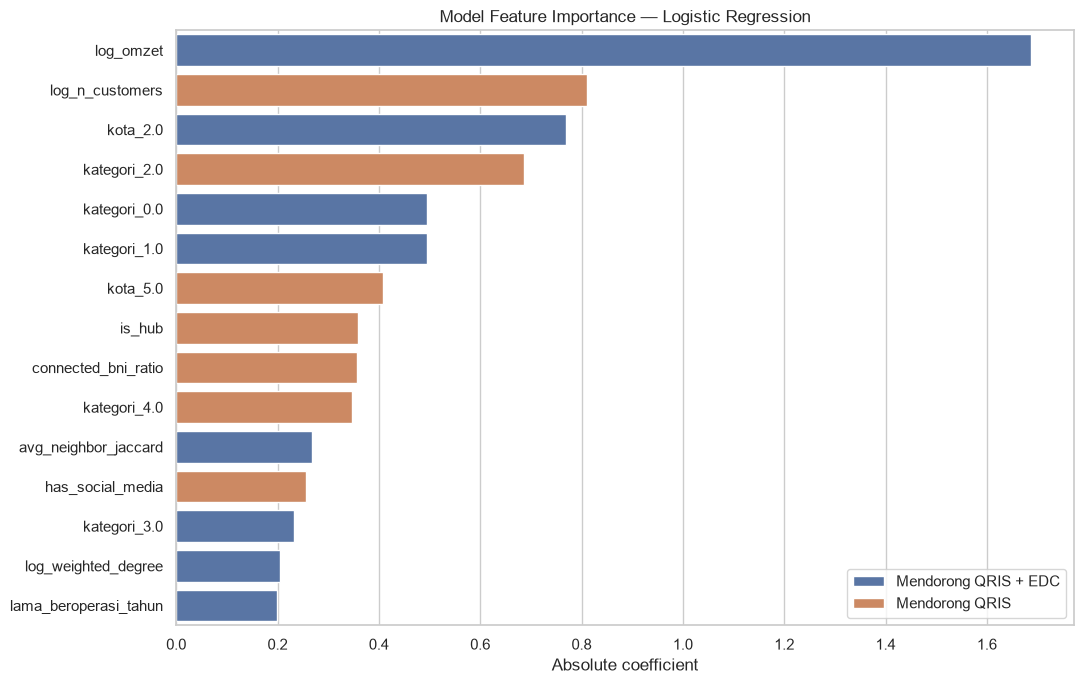

In [8]:
fitted_preprocessor = evaluation_pipeline.named_steps["preprocess"]
final_estimator = evaluation_pipeline.named_steps["model"]

preprocessed_feature_names = fitted_preprocessor.get_feature_names_out()
if "postprocess" in evaluation_pipeline.named_steps:
    fitted_postprocessor = evaluation_pipeline.named_steps["postprocess"]
    transformed_feature_names = fitted_postprocessor.get_feature_names_out(
        preprocessed_feature_names
    )
else:
    fitted_postprocessor = None
    transformed_feature_names = preprocessed_feature_names

if isinstance(final_estimator, LogisticRegression):
    signed_effect = final_estimator.coef_[0]
    model_importance = np.abs(signed_effect)
    direction = np.where(
        signed_effect >= 0,
        "Mendorong QRIS + EDC",
        "Mendorong QRIS",
    )
else:
    signed_effect = np.full(len(transformed_feature_names), np.nan)
    model_importance = final_estimator.feature_importances_
    direction = np.repeat("Importance model", len(transformed_feature_names))

feature_importance_df = (
    pd.DataFrame(
        {
            "feature": transformed_feature_names,
            "importance": model_importance,
            "signed_effect": signed_effect,
            "direction": direction,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_feature_importance = feature_importance_df.head(15)
display(top_feature_importance.round(4))

plt.figure(figsize=(11, 7))
sns.barplot(
    data=top_feature_importance,
    x="importance",
    y="feature",
    hue="direction",
    dodge=False,
)
plt.title(f"Model Feature Importance — {selected_model_name}")
plt.xlabel("Absolute coefficient" if isinstance(final_estimator, LogisticRegression) else "Importance")
plt.ylabel("")
plt.legend(title="", loc="lower right")
plt.tight_layout()
if SAVE_OUTPUTS:
    os.makedirs(PLOT_DIR, exist_ok=True)
    plt.savefig(f"{PLOT_DIR}/20_product_rec_feature_importance_v2.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. SHAP values

SHAP melengkapi feature importance dengan menunjukkan **arah dan besar kontribusi fitur pada setiap prediksi**. Nilai SHAP positif mendorong rekomendasi ke QRIS + EDC; nilai negatif mendorong ke QRIS.

- Bar plot merangkum kepentingan global berdasarkan rata-rata absolute SHAP.
- Beeswarm plot memperlihatkan arah pengaruh dan variasinya antar-merchant.

Background dataset has 369 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=369 when initializing the masker.


,feature,mean_abs_shap
0,log_omzet,1.4402
1,log_n_customers,0.5150
2,connected_bni_ratio,0.3013
3,is_hub,0.2621
4,kategori_2.0,0.2603
5,has_social_media,0.2595
6,kota_2.0,0.1914
7,has_website,0.1840
8,lama_beroperasi_tahun,0.1752
9,log_weighted_degree,0.1749


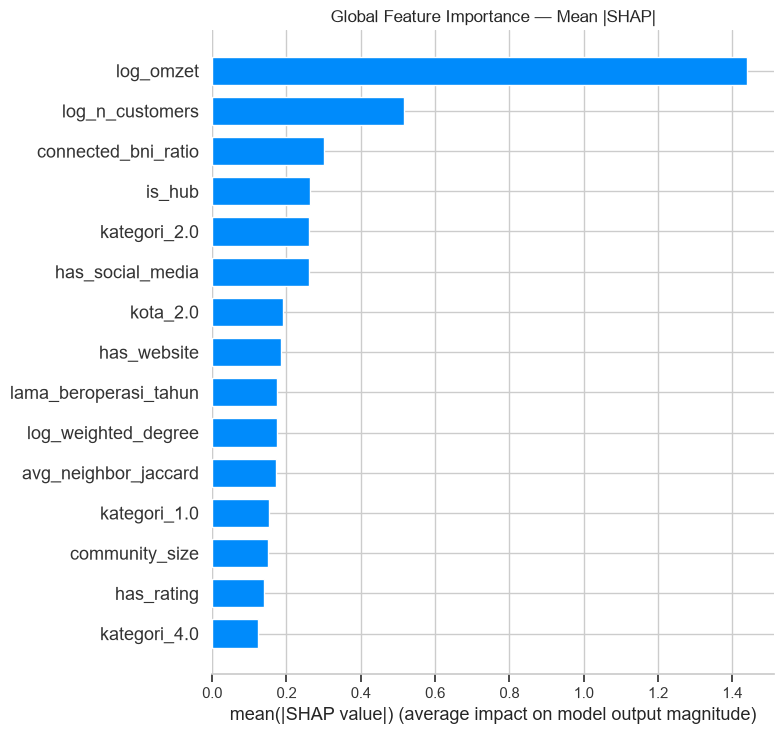

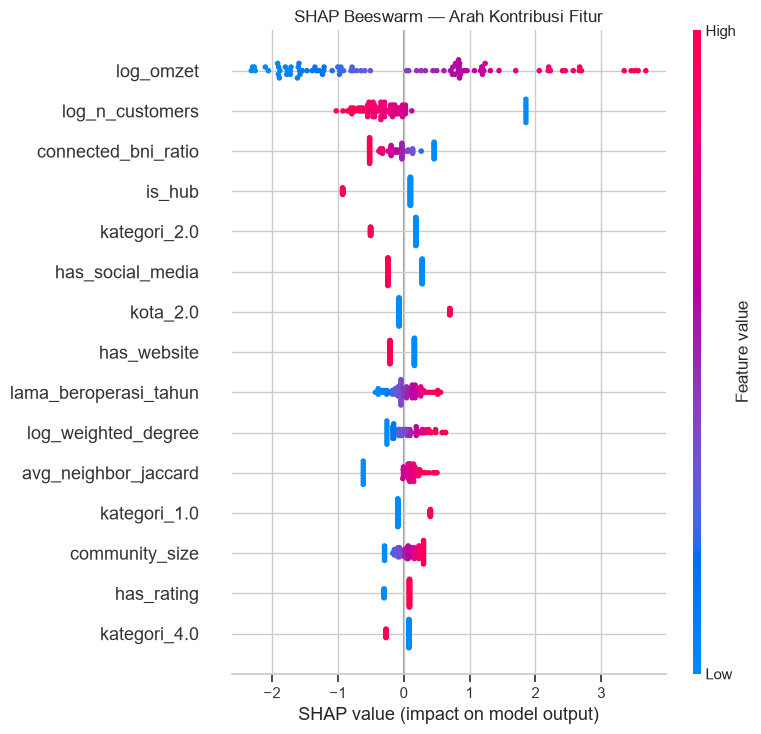

In [9]:
X_train_model = fitted_preprocessor.transform(X_train)
X_test_model = fitted_preprocessor.transform(X_test)

if fitted_postprocessor is not None:
    X_train_model = fitted_postprocessor.transform(X_train_model)
    X_test_model = fitted_postprocessor.transform(X_test_model)

X_train_model = np.asarray(X_train_model)
X_test_model = np.asarray(X_test_model)

if isinstance(final_estimator, LogisticRegression):
    shap_explainer = shap.LinearExplainer(final_estimator, X_train_model)
else:
    shap_explainer = shap.TreeExplainer(final_estimator)

shap_raw = shap_explainer.shap_values(X_test_model)
if isinstance(shap_raw, list):
    shap_values = shap_raw[1]
elif getattr(shap_raw, "ndim", 0) == 3:
    shap_values = shap_raw[:, :, 1]
else:
    shap_values = shap_raw

shap_importance_df = (
    pd.DataFrame(
        {
            "feature": transformed_feature_names,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0),
        }
    )
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
display(shap_importance_df.head(15).round(4))

shap.summary_plot(
    shap_values,
    X_test_model,
    feature_names=transformed_feature_names,
    plot_type="bar",
    max_display=15,
    show=False,
)
plt.title("Global Feature Importance — Mean |SHAP|")
plt.tight_layout()
if SAVE_OUTPUTS:
    plt.savefig(f"{PLOT_DIR}/21_product_rec_shap_bar_v2.png", dpi=150, bbox_inches="tight")
plt.show()

shap.summary_plot(
    shap_values,
    X_test_model,
    feature_names=transformed_feature_names,
    max_display=15,
    show=False,
)
plt.title("SHAP Beeswarm — Arah Kontribusi Fitur")
plt.tight_layout()
if SAVE_OUTPUTS:
    plt.savefig(f"{PLOT_DIR}/22_product_rec_shap_beeswarm_v2.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Refit pipeline produksi dan prediksi merchant non-BNI

Sesudah performa dicatat, konfigurasi terbaik di-refit pada **seluruh** merchant BNI berlabel. Tahap ini memanfaatkan data sebanyak mungkin untuk artefak produksi. Pipeline menerima kolom mentah, jadi tidak ada encoding manual yang perlu diulang.

Threshold kelas tetap `0.5`. Notebook tidak mengubah threshold hanya agar distribusi rekomendasi terlihat lebih seimbang.


In [10]:
production_pipeline = clone(evaluation_pipeline)
production_pipeline.fit(X_product, y_product)

non_bni_merchants = feature_table.loc[
    feature_table["is_bni_acquiring"].eq("Tidak")
].copy()

X_non_bni = non_bni_merchants[PRODUCT_FEATURES]
non_bni_merchants["product_rec_class"] = production_pipeline.predict(X_non_bni)
non_bni_merchants["product_rec_proba_edc"] = production_pipeline.predict_proba(X_non_bni)[:, 1]
non_bni_merchants["product_recommendation"] = non_bni_merchants[
    "product_rec_class"
].map({0: "QRIS", 1: "QRIS + EDC"})
non_bni_merchants["product_rec_source"] = "ml_pipeline_v2"

prediction_summary = (
    non_bni_merchants["product_recommendation"]
    .value_counts()
    .rename_axis("rekomendasi")
    .to_frame("jumlah")
)
prediction_summary["persentase"] = (
    100 * prediction_summary["jumlah"] / prediction_summary["jumlah"].sum()
)

print(f"Merchant non-BNI yang diprediksi: {len(non_bni_merchants):,}")
display(prediction_summary.round({"persentase": 1}))

display_cols = [
    "merchant_id",
    "nama",
    "kategori",
    "kota",
    "product_recommendation",
    "product_rec_proba_edc",
]
display(
    non_bni_merchants.nlargest(10, "product_rec_proba_edc")[display_cols]
    .reset_index(drop=True)
    .style.format({"product_rec_proba_edc": "{:.3f}"})
)


Merchant non-BNI yang diprediksi: 246


,jumlah,persentase
rekomendasi,,
QRIS + EDC,141,57.3
QRIS,105,42.7


,merchant_id,nama,kategori,kota,product_recommendation,product_rec_proba_edc
0,M0620,Sahabat Garage Distribusi,Automotive,Bogor,QRIS + EDC,0.979
1,M0274,PT Sejahtera Distribusi Sentosa,Fashion,Bogor,QRIS + EDC,0.979
2,M0580,PT Buana Komputer Sentosa,Electronics,Bandung,QRIS + EDC,0.975
3,M0646,PT Makmur Distribusi Persada,Automotive,Bogor,QRIS + EDC,0.968
4,M0224,PT Pelita Kriya Sentosa,Fashion,Depok,QRIS + EDC,0.967
5,M0376,Sejahtera Mart Distribusi,Grocery,Bogor,QRIS + EDC,0.963
6,M0265,PT Mahardika Mode Indonesia,Fashion,Tangerang,QRIS + EDC,0.962
7,M0304,PT Anugerah Kriya Indonesia,Fashion,Tangerang,QRIS + EDC,0.960
8,M0311,CV Arunika Apparel Sejahtera,Fashion,Depok,QRIS + EDC,0.959
9,M0665,PT Sejahtera Distribusi Mandiri,Automotive,Tangerang,QRIS + EDC,0.956


## 10. Simpan artefak dan gabungkan dengan output notebook 03

`product_rec_model.pkl` tetap disimpan sebagai alias kompatibilitas untuk notebook/dashboard lama. Isinya sekarang adalah pipeline lengkap, bukan classifier tanpa preprocessing. File label encoder lama diisi dictionary kosong karena encoding sudah menjadi bagian pipeline.


In [11]:
balancing_strategy = selected_sampler_name
pipeline_step_names = list(production_pipeline.named_steps.keys())

product_metadata = {
    "version": "pipeline_v2",
    "model_name": selected_model_name,
    "selection_metric": "macro_f1",
    "best_params": best_params_display,
    "best_cv_macro_f1": float(grid_search.best_score_),
    "balancing_strategy": balancing_strategy,
    "pipeline_steps": pipeline_step_names,
    "feature_columns": PRODUCT_FEATURES,
    "label_map": {0: "QRIS", 1: "QRIS + EDC"},
    "training_samples": int(len(y_product)),
    "holdout_samples": int(len(y_test)),
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "notes": (
        "Holdout hanya untuk evaluasi. Artefak produksi di-refit pada seluruh "
        "data berlabel setelah evaluasi."
    ),
}

acquisition_predictions = pd.read_csv(
    f"{DATA_DIR}/merchants_with_predictions.csv"
)

product_cols = [
    "merchant_id",
    "product_recommendation",
    "product_rec_class",
    "product_rec_proba_edc",
    "product_rec_source",
]

# Aman saat notebook dijalankan ulang: buang kolom rekomendasi lama sebelum merge.
base_predictions = acquisition_predictions.drop(
    columns=product_cols[1:],
    errors="ignore",
)
merged_predictions = base_predictions.merge(
    non_bni_merchants[product_cols],
    on="merchant_id",
    how="left",
    validate="one_to_one",
)

# Merchant BNI memakai produk existing, bukan prediksi model.
is_existing_bni = merged_predictions["is_bni_acquiring"].eq("Ya")
existing_product = merged_predictions["produk_bni"].astype("string").str.upper()
existing_has_edc = existing_product.str.contains("EDC", na=False)
existing_has_qris = existing_product.str.contains("QRIS", na=False)

merged_predictions.loc[
    is_existing_bni & existing_has_edc, "product_recommendation"
] = "QRIS + EDC"
merged_predictions.loc[
    is_existing_bni & ~existing_has_edc & existing_has_qris,
    "product_recommendation",
] = "QRIS"
merged_predictions.loc[
    is_existing_bni & (existing_has_edc | existing_has_qris),
    "product_rec_source",
] = "existing_bni"

if SAVE_OUTPUTS:
    os.makedirs(MODEL_DIR, exist_ok=True)
    joblib.dump(production_pipeline, f"{MODEL_DIR}/product_rec_pipeline.pkl")
    joblib.dump(production_pipeline, f"{MODEL_DIR}/product_rec_model.pkl")
    joblib.dump(PRODUCT_FEATURES, f"{MODEL_DIR}/product_rec_feature_cols.pkl")
    joblib.dump({}, f"{MODEL_DIR}/product_rec_label_encoders.pkl")
    joblib.dump(product_metadata, f"{MODEL_DIR}/product_rec_metadata.pkl")
    merged_predictions.to_csv(
        f"{DATA_DIR}/merchants_with_product_rec.csv",
        index=False,
    )
    print("Artefak model dan hasil rekomendasi berhasil disimpan.")
else:
    print("SAVE_OUTPUTS=False — validasi selesai tanpa menulis artefak.")

print(f"Total output merchant       : {len(merged_predictions):,}")
print(
    "Non-BNI dari pipeline v2   : "
    f"{merged_predictions['product_rec_source'].eq('ml_pipeline_v2').sum():,}"
)
print(
    "BNI dari produk existing   : "
    f"{merged_predictions['product_rec_source'].eq('existing_bni').sum():,}"
)
print(
    "Tanpa rekomendasi          : "
    f"{merged_predictions['product_recommendation'].isna().sum():,}"
)

Artefak model dan hasil rekomendasi berhasil disimpan.
Total output merchant       : 708
Non-BNI dari pipeline v2   : 246
BNI dari produk existing   : 462
Tanpa rekomendasi          : 0


## 11. Ringkasan dan batasan

Pipeline v2 memperbaiki urutan prosedural dan membuat proses inferensi lebih aman. Namun, training hanya menggunakan merchant yang sudah menjadi nasabah BNI, sedangkan target inferensi adalah merchant non-BNI. Perbedaan karakteristik kedua kelompok ini (*selection/covariate shift*) tetap menjadi batasan data yang perlu disebutkan dalam laporan capstone.

Jika CV atau holdout hanya sedikit lebih baik dari dummy baseline, kesimpulan yang tepat adalah sinyal fitur saat ini belum kuat untuk membedakan kepemilikan EDC—bukan memaksa distribusi prediksi melalui threshold manual.


In [12]:
print("=" * 68)
print("RINGKASAN PRODUCT RECOMMENDATION — PIPELINE V2")
print("=" * 68)
print(f"Model terpilih       : {selected_model_name}")
print(f"Balancing            : {balancing_strategy}")
print(f"CV Macro-F1 terbaik  : {grid_search.best_score_:.4f}")
print(f"Holdout Macro-F1     : {test_metrics['macro_f1']:.4f}")
print(f"Holdout ROC-AUC      : {test_metrics['roc_auc']:.4f}")
print(f"Training berlabel    : {len(y_product):,} merchant BNI")
print(f"Target inferensi     : {len(non_bni_merchants):,} merchant non-BNI")
print("\nPipeline produksi menerima data mentah dan menangani preprocessing otomatis.")


RINGKASAN PRODUCT RECOMMENDATION — PIPELINE V2
Model terpilih       : Logistic Regression
Balancing            : SMOTENC
CV Macro-F1 terbaik  : 0.7544
Holdout Macro-F1     : 0.7742
Holdout ROC-AUC      : 0.8274
Training berlabel    : 462 merchant BNI
Target inferensi     : 246 merchant non-BNI

Pipeline produksi menerima data mentah dan menangani preprocessing otomatis.
